## Elección del modelo de clasificación🔬 

En este notebook testeo posibles algoritmos de clasificación una vez obtenidas las caras vectorizadas y con sus respectivos labels de emoción.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

from scipy.stats import ttest_rel, wilcoxon

from skimage.feature import local_binary_pattern
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, f1_score, classification_report
from sklearn.model_selection import (
    cross_val_score,
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.decomposition import PCA

In [36]:
EMOTION_CATEGORIES = ['happy', 'sad', 'neutral']

In [37]:
def _load_dataset(faces_path: str) -> pd.DataFrame:  
    emotions_df = {}
    for emotion in EMOTION_CATEGORIES:
        df = pd.read_csv(f"{faces_path}/{emotion}_faces.csv", header=None).values
        size = df.shape[0]
        emotions_df[emotion] = {
            'features': df,
            'size': size
        }

    faces_features = np.concatenate(
        [
            emotions_df[emotion]['features']
            for emotion in EMOTION_CATEGORIES
        ], 
        axis=0
    )
    faces_features = pd.DataFrame(faces_features)

    labels = np.concatenate(
        [
            np.full(emotion_data['size'], emotion_name)
            for emotion_name, emotion_data in emotions_df.items()
        ], 
        axis=0
    )
    faces_features['label'] = labels

    return faces_features

pca_faces = _load_dataset("../data/processed/pca_faces")

In [38]:
pca_faces.groupby('label').size().reset_index(name='count')

,label,count
0,happy,3884
1,neutral,2775
2,sad,1545


In [39]:
Y = pca_faces['label']
X = pca_faces.copy().drop(columns=['label'])

### Nested Cross Validation

Para elegir la configuración óptima de KNN uso un doble loop de CV que me permite mejorar la estimación del accuracy del modelo frente a datos nuevos.

In [40]:
param_grid = {
    'n_neighbors': [3, 5, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'cosine'],
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

scores = cross_val_score(grid_search, X, Y, cv=4)

In [41]:
scores.mean()

np.float64(0.7322038030229157)

In [42]:
grid_search.fit(X, Y)

,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'cosine'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [43]:
results = pd.DataFrame(grid_search.cv_results_)
results.sort_values('rank_test_score').head(8)[
    ['param_metric', 'param_weights', 'param_n_neighbors', 'mean_test_score']
]

,param_metric,param_weights,param_n_neighbors,mean_test_score
11,cosine,distance,11,0.735860
9,cosine,distance,5,0.727937
5,euclidean,distance,11,0.727084
3,euclidean,distance,5,0.721111
7,cosine,distance,3,0.711482
1,euclidean,distance,3,0.709896
10,cosine,uniform,11,0.707825
8,cosine,uniform,5,0.704289


### Gráficos para el README
Comparación de las 12 combinaciones de hiperparámetros y F1-score por emoción de los dos mejores modelos (uno por métrica). Se guardan en `experiments/` y son los que usa `README.md`.

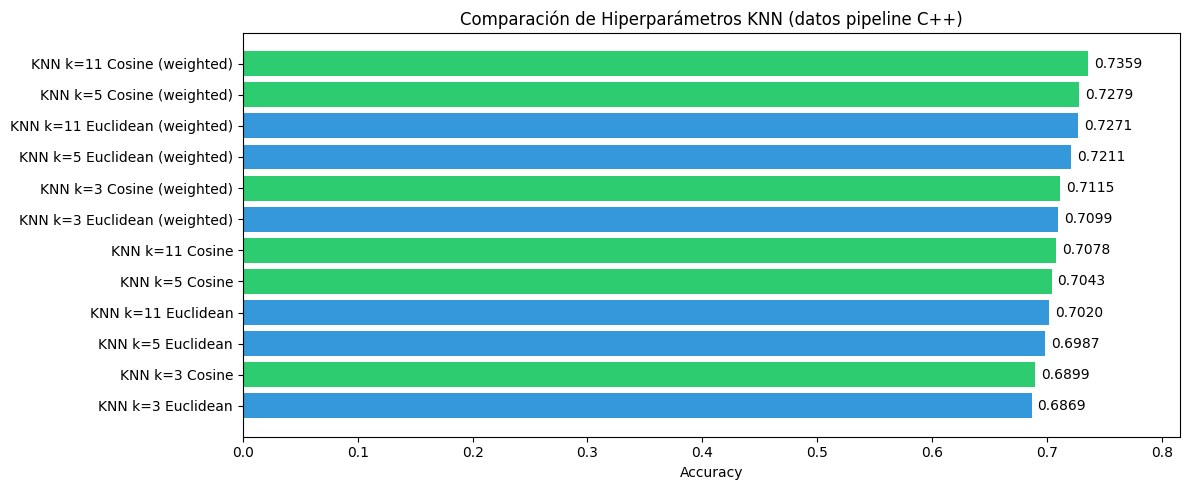

In [44]:
results['label'] = results.apply(
    lambda r: f"KNN k={r['param_n_neighbors']} {r['param_metric'].capitalize()}"
              + (" (weighted)" if r['param_weights'] == 'distance' else ""),
    axis=1
)
results['color'] = results['param_metric'].map({'euclidean': '#3498db', 'cosine': '#2ecc71'})
results_sorted = results.sort_values('mean_test_score')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(results_sorted['label'], results_sorted['mean_test_score'], color=results_sorted['color'])
for bar, score in zip(bars, results_sorted['mean_test_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2, f"{score:.4f}", va='center')
ax.set_xlabel('Accuracy')
ax.set_title('Comparación de Hiperparámetros KNN (datos pipeline C++)')
ax.set_xlim(0, results_sorted['mean_test_score'].max() + 0.08)
plt.tight_layout()
plt.savefig('hiperparametros_cpp.png', dpi=100)
plt.show()

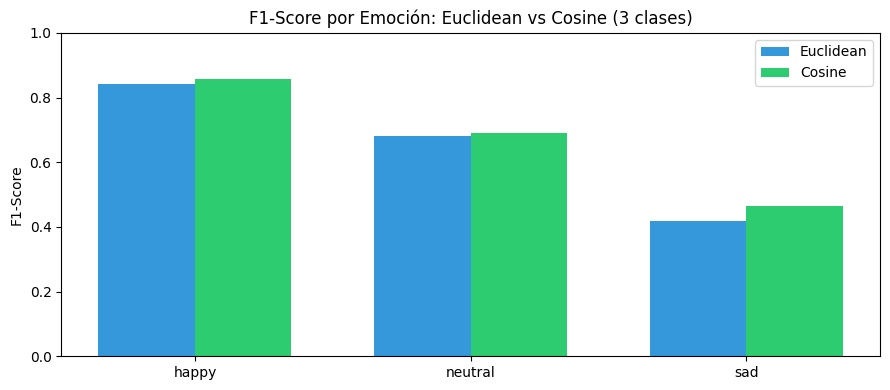

In [45]:
# Mejor combinación por métrica (según accuracy de GridSearchCV), evaluada en un holdout separado
best_euclidean = results[results['param_metric'] == 'euclidean'].sort_values('mean_test_score', ascending=False).iloc[0]
best_cosine = results[results['param_metric'] == 'cosine'].sort_values('mean_test_score', ascending=False).iloc[0]

X_train_hp, X_test_hp, y_train_hp, y_test_hp = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

def per_class_f1(row):
    clf = KNeighborsClassifier(
        n_neighbors=int(row['param_n_neighbors']),
        weights=row['param_weights'],
        metric=row['param_metric'],
    )
    clf.fit(X_train_hp, y_train_hp)
    y_pred = clf.predict(X_test_hp)
    report = classification_report(y_test_hp, y_pred, output_dict=True, zero_division=0)
    return {emotion: report[emotion]['f1-score'] for emotion in EMOTION_CATEGORIES}

f1_euclidean = per_class_f1(best_euclidean)
f1_cosine = per_class_f1(best_cosine)

order = ['happy', 'neutral', 'sad']
x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, [f1_euclidean[e] for e in order], width, label='Euclidean', color='#3498db')
ax.bar(x + width/2, [f1_cosine[e] for e in order], width, label='Cosine', color='#2ecc71')
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylim(0, 1.0)
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score por Emoción: Euclidean vs Cosine (3 clases)')
ax.legend()
plt.tight_layout()
plt.savefig('distancias.png', dpi=100)
plt.show()

## Comparación de métodos para extraer features:
1. Raw Pixels + PCA 
2. LBP + PCA 
3. HOG + PCA

In [46]:
# mismos valores que HOG_BLOCK_SIZE/STRIDE/CELL/NBINS en constants.h
HOG_PARAMS = dict(  
    _winSize=(48, 48), 
    _blockSize=(16, 16), 
    _blockStride=(8, 8), 
    _cellSize=(8, 8), 
    _nbins=9
)
_hog = cv2.HOGDescriptor(*HOG_PARAMS.values())

def extract_hog(image):
    return _hog.compute(image).flatten()

In [47]:
def extract_blocked_lbp(image, cell_size=8, radius=1, n_points=8):
    h, w = image.shape
    feats = []
    for y in range(0, h, cell_size):
        for x in range(0, w, cell_size):
            cell = image[y:y + cell_size, x:x + cell_size]
            lbp = local_binary_pattern(cell, n_points, radius, method='uniform')
            hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), density=True)
            feats.append(hist)
    return np.concatenate(feats)

In [48]:

FACES_DIR = "../data/dataset/fer2013"
MAX_PER_CLASS = None

X_raw_list, X_lbp_list, X_hog_list, Y_fair = [], [], [], []

for emotion in EMOTION_CATEGORIES:
    files = sorted(Path(f"{FACES_DIR}/{emotion}").glob("*.jpg"))
    if MAX_PER_CLASS is not None:
        files = files[:MAX_PER_CLASS]
    print(f"  {emotion}: {len(files)} caras")

    for fp in files:
        img = cv2.imread(str(fp), cv2.IMREAD_GRAYSCALE)  
        img = cv2.equalizeHist(img)                      

        X_raw_list.append(img.flatten() / 255.0)
        X_lbp_list.append(extract_blocked_lbp(img))
        X_hog_list.append(extract_hog(img))
        Y_fair.append(emotion)

X_raw_fair = np.array(X_raw_list)
X_lbp_fair = np.array(X_lbp_list)
X_hog_fair = np.array(X_hog_list)
Y_fair = np.array(Y_fair)

print(f"\nDimensiones (mismas {len(Y_fair)} imágenes para las 3):")
print(f"  Raw pixels: {X_raw_fair.shape}")
print(f"  LBP (bloqueado): {X_lbp_fair.shape}")
print(f"  HOG: {X_hog_fair.shape}")

  happy: 8989 caras
  sad: 6077 caras
  neutral: 6198 caras

Dimensiones (mismas 21264 imágenes para las 3):
  Raw pixels: (21264, 2304)
  LBP (bloqueado): (21264, 360)
  HOG: (21264, 900)


In [49]:
def evaluate_with_pca(X_feat, y, n_components=100, name=""):    
    mean_vec = X_feat.mean(axis=0)
    X_centered = X_feat - mean_vec

    n_comp = min(n_components, X_centered.shape[0], X_centered.shape[1])
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_centered)

    grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
    grid.fit(X_pca, y)

    return grid

grid_raw_fair = evaluate_with_pca(X_raw_fair, Y_fair, name="Raw pixels + PCA")
grid_lbp_fair = evaluate_with_pca(X_lbp_fair, Y_fair, name="LBP (bloqueado) + PCA")
grid_hog_fair = evaluate_with_pca(X_hog_fair, Y_fair, name="HOG + PCA")

comparison_fair_df = pd.DataFrame([
    {
        'Descriptor': 'Raw pixels + PCA', 
        'Accuracy': grid_raw_fair.best_score_, 
        **grid_raw_fair.best_params_
    },
    {
        'Descriptor': 'LBP (bloqueado) + PCA', 
        'Accuracy': grid_lbp_fair.best_score_, 
        **grid_lbp_fair.best_params_
    },
    {
        'Descriptor': 'HOG + PCA', 
        'Accuracy': grid_hog_fair.best_score_, 
        **grid_hog_fair.best_params_
    },
]).sort_values('Accuracy', ascending=False)

display(comparison_fair_df)

,Descriptor,Accuracy,metric,n_neighbors,weights
2,HOG + PCA,0.676730,cosine,11,distance
0,Raw pixels + PCA,0.566027,cosine,11,distance
1,LBP (bloqueado) + PCA,0.507007,cosine,11,distance


## Testeo mejora de sub-samplear clases

In [50]:
pca_faces.groupby('label').size().reset_index(name='count')

,label,count
0,happy,3884
1,neutral,2775
2,sad,1545


In [51]:
def make_pipeline(ratio):
    n_sad = (Y == 'sad').sum()
    target_happy = min(int(n_sad * ratio), (Y == 'happy').sum())
    sampler = RandomUnderSampler(
        sampling_strategy={'happy': target_happy},  # solo toca happy, igual que el C++
        random_state=None,  # replicar que el C++ no fija semilla
    )
    knn = KNeighborsClassifier(n_neighbors=11, weights='distance', metric='euclidean')
    return Pipeline([('under', sampler), ('knn', knn)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for ratio in [None, 0.75, 1.0, 1.5, 2.0]:
    fold_scores = []
    pipe = make_pipeline(ratio) \
        if ratio else KNeighborsClassifier(
            n_neighbors=11, 
            weights='distance', 
            metric='euclidean'
        )
    scores = cross_val_score(pipe, X, Y, cv=cv, scoring='f1_macro')
    fold_scores.extend(scores)
    results[ratio] = np.array(fold_scores)
    print(ratio, results[ratio].mean(), results[ratio].std())

None 0.6252982481167633 0.017364632576299784
0.75 0.6266941970359232 0.013707974528736875
1.0 0.6382233419693513 0.014987669482553211
1.5 0.6334878162429376 0.011453658136354067
2.0 0.6252994099613918 0.017229503591486124


In [52]:
baseline = results[None]
print(f"{'ratio':>6} {'mean_diff':>10} {'ttest_p':>10} {'wilcoxon_p':>12}")
for ratio in [0.75, 1.0, 1.5, 2.0]:
    diff = results[ratio] - baseline
    _, t_p = ttest_rel(results[ratio], baseline)
    _, w_p = wilcoxon(results[ratio], baseline)
    print(f"{str(ratio):>6} {diff.mean():>10.4f} {t_p:>10.4f} {w_p:>12.4f}")

 ratio  mean_diff    ttest_p   wilcoxon_p
  0.75     0.0014     0.7286       0.8125
   1.0     0.0129     0.0515       0.1250
   1.5     0.0082     0.2125       0.3125
   2.0     0.0000     0.9945       0.8750
